**Importing required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

**Loading Dataset & Basic understanding**

In [2]:
df = pd.read_csv("Intern Performance Dataset Task 2.csv")

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee_ID             500 non-null    int64 
 1   Age                     500 non-null    int64 
 2   Education_Level         500 non-null    object
 3   Years_of_Experience     500 non-null    int64 
 4   Programming_Skill       500 non-null    object
 5   Python_Score            500 non-null    int64 
 6   ML_Theory_Score         500 non-null    int64 
 7   Project_Score           500 non-null    int64 
 8   Attendance_Percentage   500 non-null    int64 
 9   Internship_Performance  500 non-null    object
dtypes: int64(7), object(3)
memory usage: 39.2+ KB


,0
Employee_ID,0
Age,0
Education_Level,0
Years_of_Experience,0
Programming_Skill,0
Python_Score,0
ML_Theory_Score,0
Project_Score,0
Attendance_Percentage,0
Internship_Performance,0


**Data Cleaning & Encode Categorical Variables**

In [3]:
# Drop irrelevant identifier column
df.drop(columns=['Employee_ID'], inplace=True)

edu_le = LabelEncoder()
prog_le = LabelEncoder()
target_le = LabelEncoder()

df['Education_Level'] = edu_le.fit_transform(df['Education_Level'])
df['Programming_Skill'] = prog_le.fit_transform(df['Programming_Skill'])
df['Internship_Performance'] = target_le.fit_transform(df['Internship_Performance'])

# Target label mapping for interpretation
performance_label_mapping = dict(
    zip(target_le.classes_, target_le.transform(target_le.classes_))
)
performance_label_mapping

{'Average': np.int64(0),
 'Excellent': np.int64(1),
 'Good': np.int64(2),
 'Poor': np.int64(3)}

**EDA**

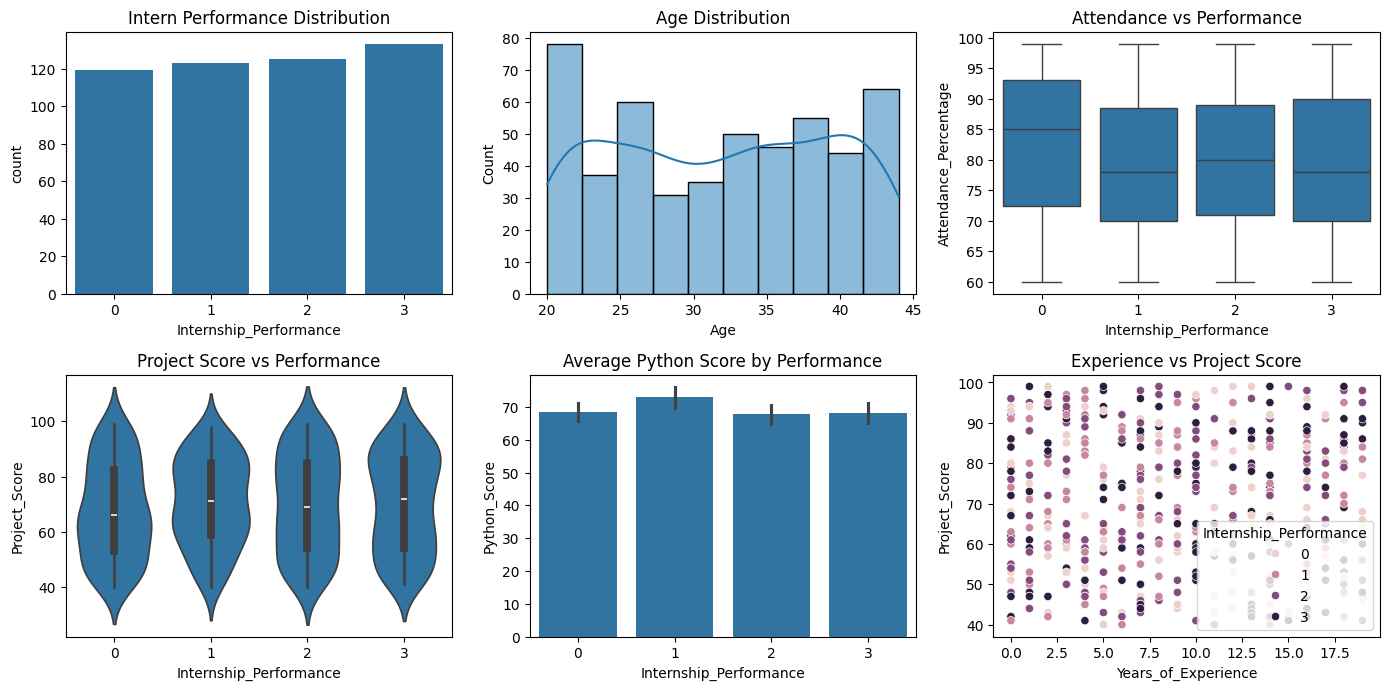

In [4]:
plt.figure(figsize=(14,10))

# 1. Target Distribution
plt.subplot(3,3,1)
sns.countplot(x='Internship_Performance', data=df)
plt.title("Intern Performance Distribution")

# 2. Age Distribution
plt.subplot(3,3,2)
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")

# 3. Attendance vs Performance
plt.subplot(3,3,3)
sns.boxplot(x='Internship_Performance', y='Attendance_Percentage', data=df)
plt.title("Attendance vs Performance")

# 4. Project Score Distribution
plt.subplot(3,3,4)
sns.violinplot(x='Internship_Performance', y='Project_Score', data=df)
plt.title("Project Score vs Performance")

# 5. Python Score vs Performance
plt.subplot(3,3,5)
sns.barplot(
    x='Internship_Performance',
    y='Python_Score',
    data=df,
    estimator=np.mean
)
plt.title("Average Python Score by Performance")

# 6. Experience vs Project Score
plt.subplot(3,3,6)
sns.scatterplot(
    x='Years_of_Experience',
    y='Project_Score',
    hue='Internship_Performance',
    data=df
)
plt.title("Experience vs Project Score")

plt.tight_layout()
plt.show()


**Correlation Analysis**

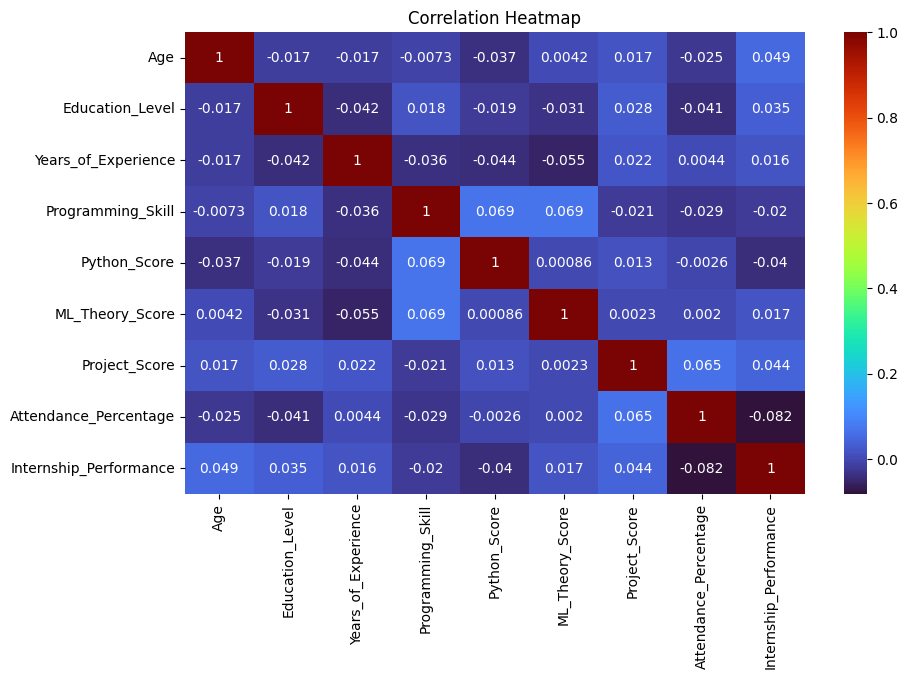

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='turbo')
plt.title("Correlation Heatmap")
plt.show()

**Feature Importance**

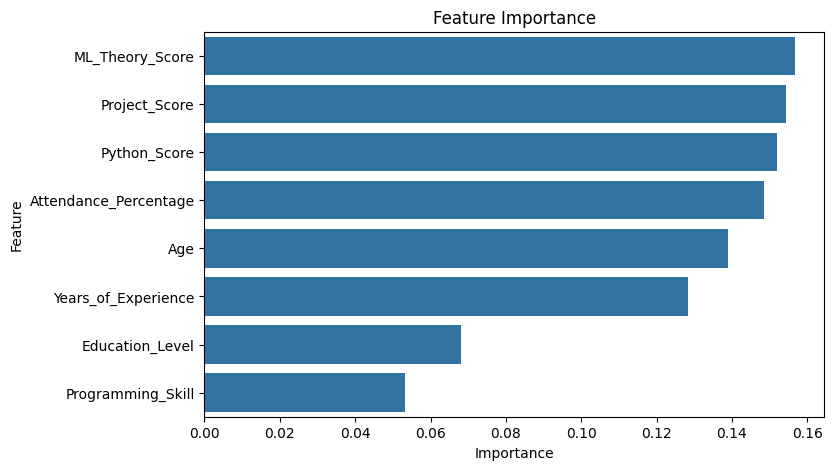

In [6]:
X_temp = df.drop('Internship_Performance', axis=1)
y_temp = df['Internship_Performance']

rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_temp, y_temp)

feature_importance = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()


**Feature / Target Split & Train-Test split**

In [7]:
X = df.drop('Internship_Performance', axis=1)
y = df['Internship_Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Feature Scaling**

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Initialization**

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

**Model Training**

In [10]:
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

**Predictions**

In [11]:
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)
xgb_pred = np.argmax(xgb.predict_proba(X_test), axis=1)

**Model Evaluations**


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.18      0.17      0.17        24
           1       0.24      0.20      0.22        25
           2       0.19      0.16      0.17        25
           3       0.22      0.31      0.26        26

    accuracy                           0.21       100
   macro avg       0.21      0.21      0.21       100
weighted avg       0.21      0.21      0.21       100



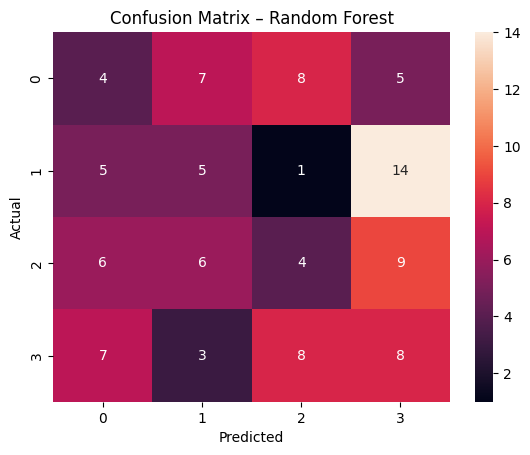


========== SVM ==========
              precision    recall  f1-score   support

           0       0.22      0.25      0.24        24
           1       0.21      0.16      0.18        25
           2       0.25      0.16      0.20        25
           3       0.21      0.31      0.25        26

    accuracy                           0.22       100
   macro avg       0.22      0.22      0.22       100
weighted avg       0.22      0.22      0.22       100



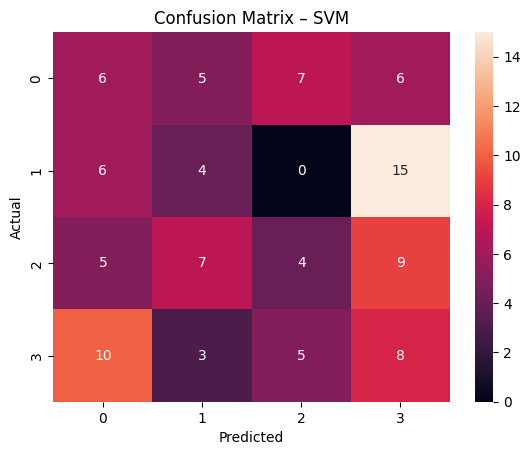


========== XGBoost ==========
              precision    recall  f1-score   support

           0       0.08      0.08      0.08        24
           1       0.20      0.20      0.20        25
           2       0.21      0.20      0.20        25
           3       0.26      0.27      0.26        26

    accuracy                           0.19       100
   macro avg       0.19      0.19      0.19       100
weighted avg       0.19      0.19      0.19       100



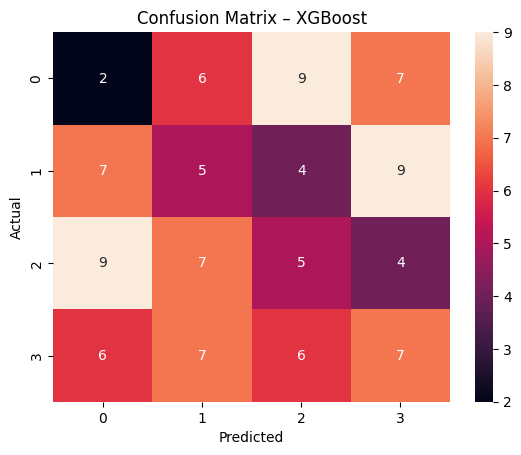

In [12]:
models = {
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "XGBoost": xgb_pred
}

results = {}

for name, preds in models.items():
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1": f1_score(y_test, preds, average='weighted')
    }

    print(f"\n========== {name} ==========")
    print(classification_report(y_test, preds))

    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d')
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


**Best Model Selection**

In [13]:
best_model = max(results, key=lambda x: results[x]['F1'])

print("Final Model Comparison (Weighted F1-Score)")
print("-" * 45)

for model, metrics in results.items():
    print(f"{model}: F1 = {metrics['F1']:.4f}")

print("\n✅ Best Performing Model:", best_model)

Final Model Comparison (Weighted F1-Score)
---------------------------------------------
Random Forest: F1 = 0.2067
SVM: F1 = 0.2157
XGBoost: F1 = 0.1897

✅ Best Performing Model: SVM
